In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/sample_data/studentperformance_preprocessed.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Percentage
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Total Score                  1000 non-null   int64  
 9   Percentage                   1000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 78.3+ KB


In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Percentage
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [5]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Percentage
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333
999,female,group D,some college,free/reduced,none,77,86,86,249,83.000000


In [6]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Total Score', 'Percentage'],
      dtype='object')

In [7]:
df.describe()

,math score,reading score,writing score,Total Score,Percentage
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000


In [8]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0
Total Score,0
Percentage,0


In [9]:
df.shape

(1000, 10)

In [10]:
score_columns=['math score','reading score','writing score']

In [11]:
df[score_columns].head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [12]:
demographic_columns=['gender','race/ethnicity','parental level of education','lunch','test preparation course']
df[demographic_columns].head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none
3,male,group A,associate's degree,free/reduced,none
4,male,group C,some college,standard,none


In [13]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [14]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [15]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [16]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

Grouped Bar chart - Parental Education

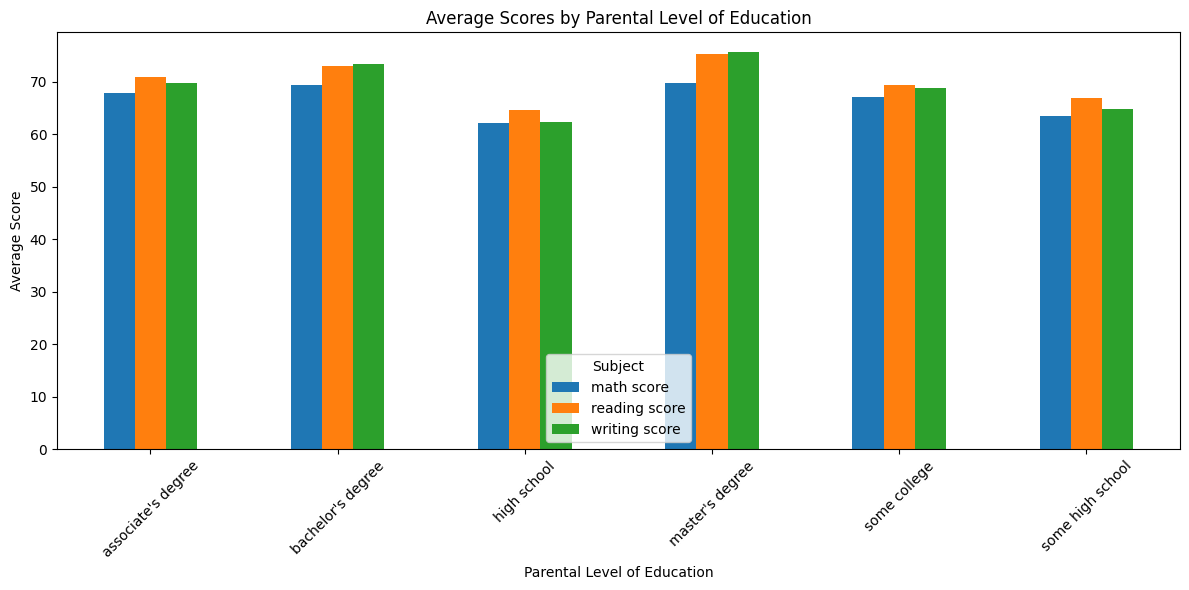

In [17]:
parental_scores = df.groupby('parental level of education')[score_columns].mean()
parental_scores.plot(kind='bar',figsize=(12,6))
plt.title('Average Scores by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

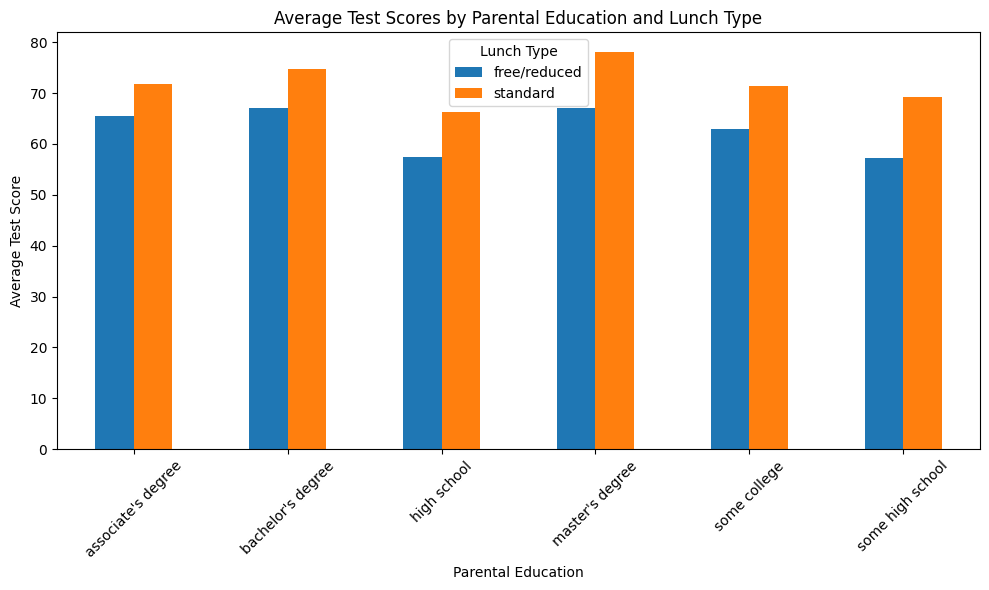

In [20]:

df["Average"] = df[["math score","reading score","writing score"]].mean(axis=1)

data = df.groupby(
    ["parental level of education", "lunch"]
)["Average"].mean().unstack()

data.plot(kind="bar", figsize=(10,6))

plt.xlabel("Parental Education")
plt.ylabel("Average Test Score")
plt.title("Average Test Scores by Parental Education and Lunch Type")
plt.xticks(rotation=45)
plt.legend(title="Lunch Type")
plt.tight_layout()
plt.show()

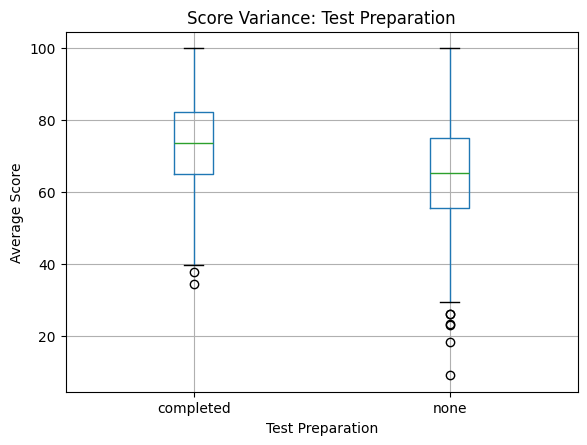

In [21]:

df["Average Score"] = df[["math score", "reading score",
                          "writing score"]].mean(axis=1)

df.boxplot(column="Average Score", by="test preparation course")

plt.title("Score Variance: Test Preparation")
plt.suptitle("")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")
plt.show()

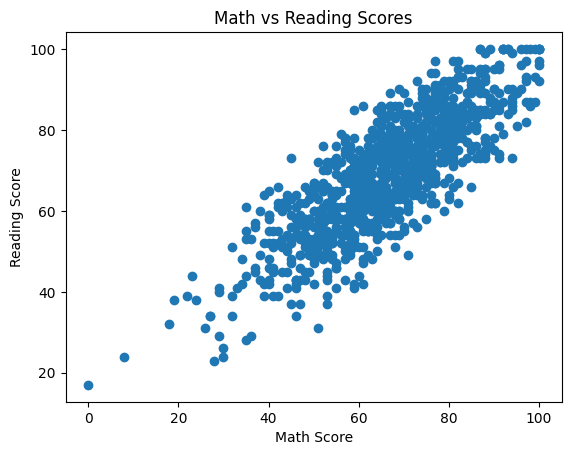

In [22]:

plt.scatter(df["math score"], df["reading score"])
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Math vs Reading Scores")
plt.show()

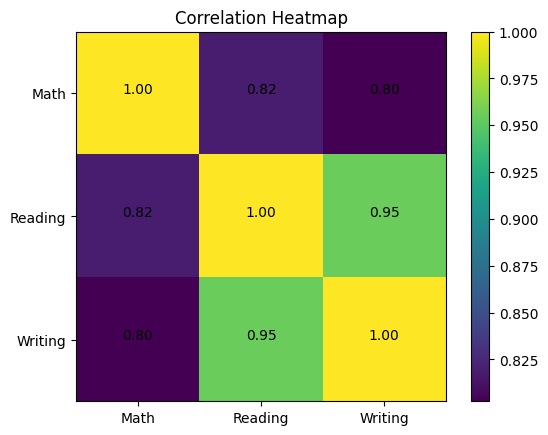

In [23]:
corr = df[["math score","reading score","writing score"]].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(3), ["Math","Reading","Writing"])
plt.yticks(range(3), ["Math","Reading","Writing"])

for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center")

plt.title("Correlation Heatmap")
plt.show()